In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/products.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/order_products__train.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/orders.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/order_products__prior.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/aisles.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/departments.csv


## Data Preprocessing

Before applying data mining techniques, the raw Instacart dataset is preprocessed to ensure efficiency and accuracy of results. The dataset is highly large-scale, so preprocessing is essential to reduce complexity and improve performance.


In [2]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
BASE = '/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/'

orders     = pd.read_csv(BASE + 'orders.csv')
order_prod = pd.read_csv(BASE + 'order_products__prior.csv')
products   = pd.read_csv(BASE + 'products.csv')
aisles     = pd.read_csv(BASE + 'aisles.csv')
departments= pd.read_csv(BASE + 'departments.csv')

print(f"Orders:          {orders.shape}")
print(f"Order-products:  {order_prod.shape}")
print(f"Products:        {products.shape}")

Orders:          (3421083, 7)
Order-products:  (32434489, 4)
Products:        (49688, 4)


In [4]:
df = order_prod.merge(products[['product_id', 'product_name']], on='product_id')

# Sample 50k orders for speed (increase if you want more coverage)
sample_orders = orders['order_id'].sample(50_000, random_state=42)
df = df[df['order_id'].isin(sample_orders)]

print(f"\nWorking with {df['order_id'].nunique():,} orders, "
      f"{df['product_name'].nunique():,} unique products")


Working with 47,012 orders, 28,917 unique products


In [5]:
baskets = df.groupby('order_id')['product_name'].apply(list).tolist()

# Keep only products appearing in ≥200 orders (reduces matrix size)
freq_counts = Counter(item for basket in baskets for item in basket)
valid_items = {item for item, cnt in freq_counts.items() if cnt >= 200}

baskets_filtered = [[i for i in b if i in valid_items] for b in baskets]
baskets_filtered = [b for b in baskets_filtered if len(b) >= 2]

print(f"After filtering: {len(baskets_filtered):,} baskets, {len(valid_items):,} items")


After filtering: 31,273 baskets, 322 items


In [6]:
#one hot encode
te = TransactionEncoder()
te_array = te.fit_transform(baskets_filtered)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

---
##  Association Rule Mining 

Association Rule Mining uncovers relationships between products that are 
frequently purchased together. We apply the **FP-Growth** algorithm, which 
is faster than Apriori on large datasets 
### Key Metrics
| Metric | Definition |
|---|---|
| **Support** | Fraction of baskets containing the itemset |
| **Confidence** | P(B given A) — how often B is bought when A is bought |
| **Lift** | How much more likely A and B are bought together vs. independently. Lift > 1 = genuine association |

### Parameters chosen
- `min_support = 0.02` → itemset must appear in at least 2% of baskets
- `max_len = 3` → consider itemsets up to size 3 (pairs and triplets)

In [7]:
#FP groewth
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=0.02,
    use_colnames=True,
    max_len=3
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")

Frequent itemsets found: 76


### Itemset Length Breakdown

Before generating rules, we examine how many itemsets were found 
at each length (1-item, 2-item, 3-item). This tells us how rich 
the co-purchase relationships are in the data.

In [8]:
length_summary = frequent_itemsets.groupby('length').agg(
    count=('support', 'count'),
    avg_support=('support', 'mean')
).round(4)

print("Frequent Itemsets by Length:")
print(length_summary.to_string())

Frequent Itemsets by Length:
        count  avg_support
length                    
1          69       0.0412
2           7       0.0254


### Generating Association Rules

From the frequent itemsets, we derive **association rules** using 
**lift** as the filtering metric with a minimum threshold of **1.2**.  

Lift ≥ 1.2 means the two items are at least 20% more likely to be 
bought together than by random chance — filtering out weak or 
coincidental associations.

In [9]:
#Rules Generation
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.2
)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"Association rules found: {len(rules)}")


Association rules found: 10


### Top 10 Rules by Lift

The table below shows the strongest product associations discovered. 
Rules are sorted by **lift** (strongest association first).

In [10]:
# Top 10 Rules
top_rules = rules[['antecedents','consequents','support','confidence','lift']].head(10).copy()
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
print("Top 10 Association Rules by Lift: ")
print(top_rules.to_string(index=False))

Top 10 Association Rules by Lift: 
           antecedents            consequents  support  confidence     lift
Bag of Organic Bananas   Organic Hass Avocado 0.028907    0.174047 1.773532
  Organic Hass Avocado Bag of Organic Bananas 0.028907    0.294558 1.773532
          Strawberries                 Banana 0.020657    0.327089 1.576124
                Banana           Strawberries 0.020657    0.099538 1.576124
                Banana        Organic Avocado 0.025965    0.125116 1.544096
       Organic Avocado                 Banana 0.025965    0.320442 1.544096
  Organic Strawberries Bag of Organic Bananas 0.028843    0.238877 1.438276
Bag of Organic Bananas   Organic Strawberries 0.028843    0.173662 1.438276
Bag of Organic Bananas   Organic Baby Spinach 0.023663    0.142472 1.308910
  Organic Baby Spinach Bag of Organic Bananas 0.023663    0.217391 1.308910


### High-Confidence Rules (Confidence ≥ 25%)

Confidence measures how reliably B is purchased when A is purchased. 
Rules with confidence ≥ 0.25 are strong enough to power a 
**"Customers also buy..."** recommendation feature directly.

In [11]:
#High Confidence Filter
high_conf = rules[rules['confidence'] >= 0.25].copy()
high_conf['antecedents'] = high_conf['antecedents'].apply(lambda x: ', '.join(list(x)))
high_conf['consequents'] = high_conf['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"High-confidence rules (confidence ≥ 0.25): {len(high_conf)}")
print(high_conf[['antecedents','consequents','support','confidence','lift']].to_string(index=False))

High-confidence rules (confidence ≥ 0.25): 3
         antecedents            consequents  support  confidence     lift
Organic Hass Avocado Bag of Organic Bananas 0.028907    0.294558 1.773532
        Strawberries                 Banana 0.020657    0.327089 1.576124
     Organic Avocado                 Banana 0.025965    0.320442 1.544096


### 📌 Interpretation & Business Insights

The association rules reveal strong co-purchase relationships between 
frequently bought grocery items. The strongest pattern is between 
**Organic Hass Avocado** and **Bag of Organic Bananas** (lift ≈ 1.77), 
meaning customers are **77% more likely** to buy these two items together 
than if they were purchasing independently.

All top rules involve organic products — bananas, avocados, strawberries, 
and spinach — suggesting a distinct **"healthy organic shopper"** behavior 
pattern in the data.

Rules appear in both directions (A → B and B → A) with the same lift but 
different confidence values. This is because confidence depends on the 
individual popularity of each item — not buying sequence, since basket 
data has no inherent order.

### 📌 Actionable Recommendations

| Rule | Recommendation |
|---|---|
| Organic Bananas ↔ Organic Avocado | Bundle as a promotional combo offer |
| Strawberries ↔ Banana | Surface together on the app or homepage |
| Organic Baby Spinach → Organic Bananas | Target spinach buyers with banana promotions |

These insights feed into **visualizations** (support vs. confidence 
scatter plot) and complement the **PageRank-based** product importance 
rankings produced by Person 3.

---
##  Exporting Results 

The association rules generated above are exported to a CSV file so that
**(Visualization)** can use them directly to build the
***support vs. confidence scatter plot without re-running the mining pipeline.***

### Output file
| File | Contents |
|---|---|
| `output/frequent_combinations.csv` | All association rules with support, confidence, and lift |

In [12]:
# Export results
import os
os.makedirs('output', exist_ok=True)

# Save association rules
rules_export = rules.copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))
rules_export.to_csv('output/frequent_combinations.csv', index=False)

print("Saved: output/frequent_combinations.csv")
print(f"Shape: {rules_export.shape}")

Saved: output/frequent_combinations.csv
Shape: (10, 14)


## Graph-Based Analysis (PageRank)


In [13]:
# PAGERANK ON CO-PURCHASE GRAPH 
G = nx.Graph()

for basket in baskets_filtered:
    unique_items = list(set(basket))
    for i in range(len(unique_items)):
        for j in range(i + 1, len(unique_items)):
            a, b = unique_items[i], unique_items[j]
            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

pagerank_scores = nx.pagerank(G, weight='weight', alpha=0.85)
pr_df = pd.DataFrame.from_dict(
    pagerank_scores, orient='index', columns=['pagerank']
).sort_values('pagerank', ascending=False)
pr_df['order_count'] = pr_df.index.map(freq_counts)

print("\nTop 20 Products by PageRank")
print(pr_df.head(20).to_string())

Graph: 322 nodes, 46748 edges

Top 20 Products by PageRank
                          pagerank  order_count
Banana                    0.028312         6997
Bag of Organic Bananas    0.023810         5529
Organic Strawberries      0.019771         3921
Organic Baby Spinach      0.018576         3531
Organic Hass Avocado      0.016605         3158
Organic Avocado           0.013475         2621
Large Lemon               0.012287         2235
Limes                     0.012145         2065
Organic Raspberries       0.010973         2033
Organic Garlic            0.009772         1541
Organic Whole Milk        0.009680         1993
Organic Yellow Onion      0.009669         1631
Organic Zucchini          0.009526         1557
Strawberries              0.008844         2111
Cucumber Kirby            0.008037         1453
Organic Grape Tomatoes    0.007628         1241
Organic Blueberries       0.007342         1474
Organic Cucumber          0.007282         1184
Organic Lemon             0.0

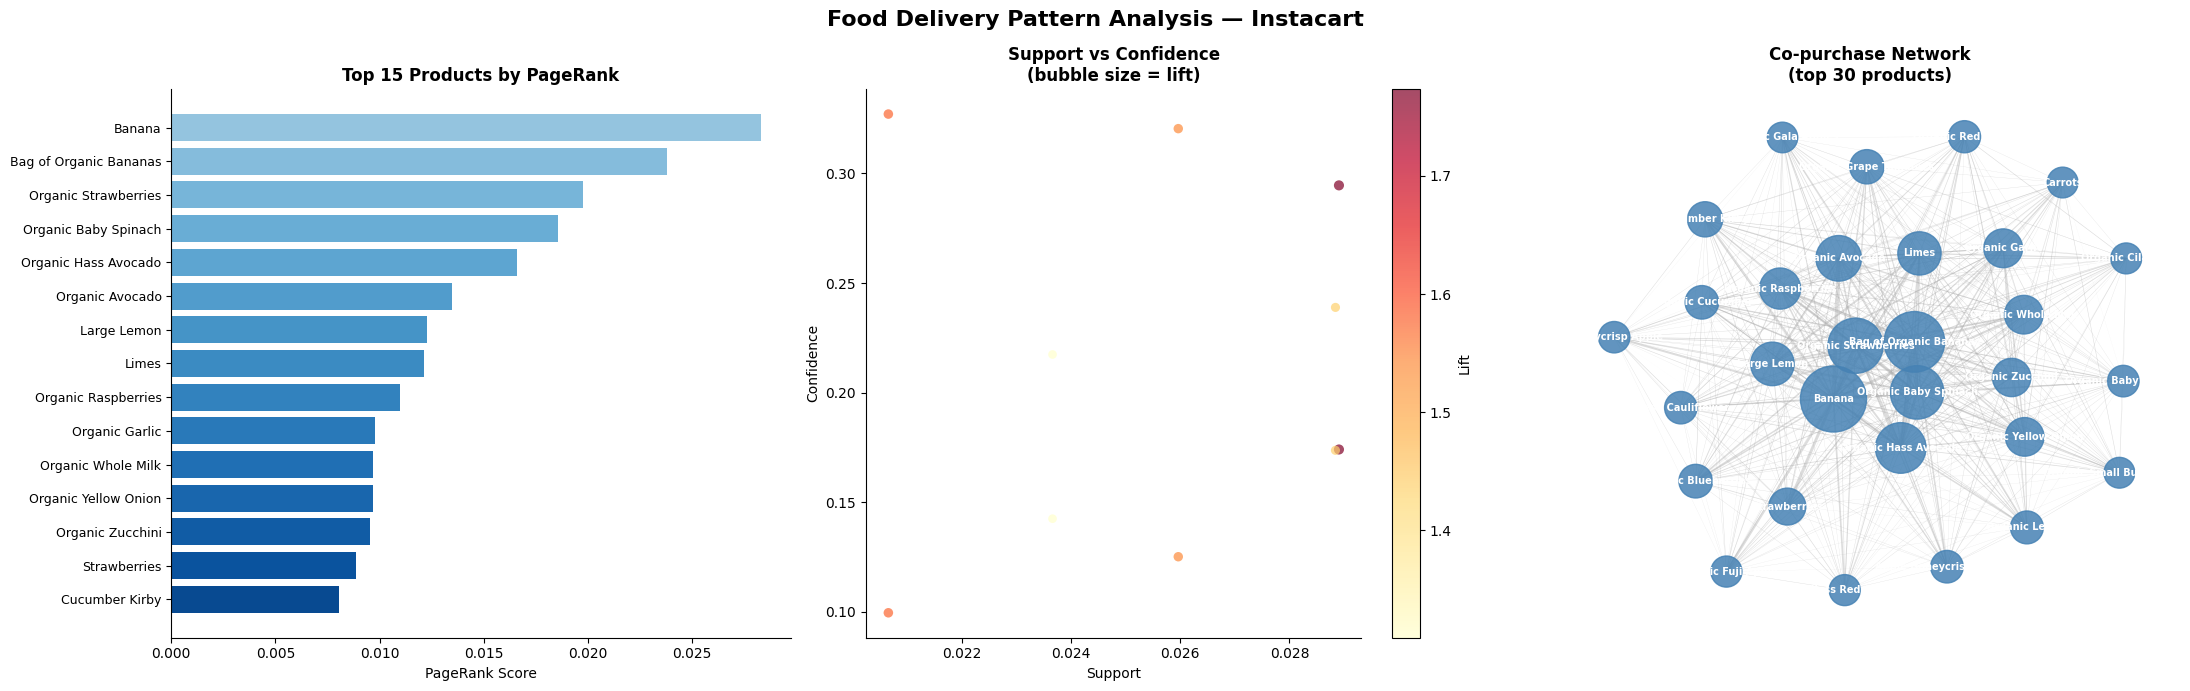

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Food Delivery Pattern Analysis — Instacart', fontsize=16, fontweight='bold')

ax1 = axes[0]
top_pr = pr_df.head(15)
colors = cm.Blues(np.linspace(0.4, 0.9, 15))[::-1]
ax1.barh(top_pr.index[::-1], top_pr['pagerank'][::-1], color=colors)
ax1.set_title('Top 15 Products by PageRank', fontweight='bold')
ax1.set_xlabel('PageRank Score')
ax1.tick_params(axis='y', labelsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = axes[1]
scatter = ax2.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd',
    s=rules['lift'] * 30, alpha=0.7, edgecolors='none'
)
plt.colorbar(scatter, ax=ax2, label='Lift')
ax2.set_xlabel('Support')
ax2.set_ylabel('Confidence')
ax2.set_title('Support vs Confidence\n(bubble size = lift)', fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax3 = axes[2]
top_nodes = list(pr_df.head(30).index)
subG = G.subgraph(top_nodes).copy()
pos = nx.spring_layout(subG, seed=42, k=2)

if subG.number_of_edges() > 0:
    edge_weights = [subG[u][v]['weight'] for u, v in subG.edges()]
    max_w = max(edge_weights)
    edge_widths = [w / max_w * 3 for w in edge_weights]
    nx.draw_networkx_edges(subG, pos, ax=ax3, width=edge_widths, alpha=0.4, edge_color='#aaa')

node_sizes = [pagerank_scores.get(n, 0) * 80000 for n in subG.nodes()]
nx.draw_networkx_nodes(subG, pos, ax=ax3, node_size=node_sizes, node_color='steelblue', alpha=0.85)

try:
    nx.draw_networkx_labels(subG, pos, ax=ax3, font_size=7, font_color='white', font_weight='bold')
except TypeError:
    nx.draw_networkx_labels(subG, pos, ax=ax3, font_size=7)

ax3.set_title('Co-purchase Network\n(top 30 products)', fontweight='bold')
ax3.axis('off')

plt.tight_layout()
plt.savefig('', dpi=150, bbox_inches='tight')
plt.show()